# SSI index


In [1]:
from __future__ import annotations
import os
import time
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import shapely.geometry
import matplotlib.pyplot as plt
import osmnx as ox
from scipy import stats

In [2]:
# ============================================================
# CONFIGURATIE
# ============================================================

ERA5_PATHS = [
    '//Users/axelleclaes/Desktop/wetransfer_thesis_2025-11-07_0852/wind_gust_00_03',
    '//Users/axelleclaes/Desktop/wetransfer_thesis_2025-11-07_0852/wind_gust_04_07',
    '//Users/axelleclaes/Desktop/wetransfer_thesis_2025-11-07_0852/wind_gust_08_11',
    '//Users/axelleclaes/Desktop/wetransfer_thesis_2025-11-07_0852/wind_gust_12_14',
    '/Users/axelleclaes/Desktop/Data België/2015/data_stream-oper_stepType-max.nc',
    '/Users/axelleclaes/Desktop/Data België/2016/data_stream-oper_stepType-max.nc',
    '/Users/axelleclaes/Desktop/Data België/2017/data_stream-oper_stepType-max.nc',
    '/Users/axelleclaes/Desktop/Data België/2018/data_stream-oper_stepType-max.nc',
    '/Users/axelleclaes/Desktop/Data België/2019/data_stream-oper_stepType-max.nc',
    '/Users/axelleclaes/Desktop/Data België/2020/data_stream-oper_stepType-max.nc',
    '/Users/axelleclaes/Desktop/Data België/2021/data_stream-oper_stepType-max.nc',
    '/Users/axelleclaes/Desktop/Data België/2022/data_stream-oper_stepType-max.nc',
    '/Users/axelleclaes/Desktop/Data België/2023/data_stream-oper_stepType-max.nc',
    '/Users/axelleclaes/Desktop/Data België/2024/data_stream-oper_stepType-max.nc',
]

GEMEENTEN = [
    'Aarschot, Vlaams-Brabant, Belgium',
    'Affligem, Vlaams-Brabant, Belgium',
    'Asse, Vlaams-Brabant, Belgium',
    'Beersel, Vlaams-Brabant, Belgium',
    'Begijnendijk, Vlaams-Brabant, Belgium',
    'Bekkevoort, Vlaams-Brabant, Belgium',
    'Bertem, Vlaams-Brabant, Belgium',
    'Bever, Vlaams-Brabant, Belgium',
    'Bierbeek, Vlaams-Brabant, Belgium',
    'Boortmeerbeek, Vlaams-Brabant, Belgium',
    'Boutersem, Vlaams-Brabant, Belgium',
    'Diest, Vlaams-Brabant, Belgium',
    'Dilbeek, Vlaams-Brabant, Belgium',
    'Drogenbos, Vlaams-Brabant, Belgium',
    'Geetbets, Vlaams-Brabant, Belgium',
    'Glabbeek, Vlaams-Brabant, Belgium',
    'Gooik, Vlaams-Brabant, Belgium',
    'Grimbergen, Vlaams-Brabant, Belgium',
    'Haacht, Vlaams-Brabant, Belgium',
    'Halle, Vlaams-Brabant, Belgium',
    'Herent, Vlaams-Brabant, Belgium',
    'Hoegaarden, Vlaams-Brabant, Belgium',
    'Hoeilaart, Vlaams-Brabant, Belgium',
    'Holsbeek, Vlaams-Brabant, Belgium',
    'Huldenberg, Vlaams-Brabant, Belgium',
    'Kampenhout, Vlaams-Brabant, Belgium',
    'Kapelle-op-den-Bos, Vlaams-Brabant, Belgium',
    'Keerbergen, Vlaams-Brabant, Belgium',
    'Kortenaken, Vlaams-Brabant, Belgium',
    'Kortenberg, Vlaams-Brabant, Belgium',
    'Kraainem, Vlaams-Brabant, Belgium',
    'Landen, Vlaams-Brabant, Belgium',
    'Lennik, Vlaams-Brabant, Belgium',
    'Leuven, Vlaams-Brabant, Belgium',
    'Liedekerke, Vlaams-Brabant, Belgium',
    'Linkebeek, Vlaams-Brabant, Belgium',
    'Linter, Vlaams-Brabant, Belgium',
    'Londerzeel, Vlaams-Brabant, Belgium',
    'Lubbeek, Vlaams-Brabant, Belgium',
    'Machelen, Vlaams-Brabant, Belgium',
    'Meise, Vlaams-Brabant, Belgium',
    'Merchtem, Vlaams-Brabant, Belgium',
    'Opwijk, Vlaams-Brabant, Belgium',
    'Oud-Heverlee, Vlaams-Brabant, Belgium',
    'Overijse, Vlaams-Brabant, Belgium',
    'Pajottegem, Vlaams-Brabant, Belgium',
    'Pepingen, Vlaams-Brabant, Belgium',
    'Roosdaal, Vlaams-Brabant, Belgium',
    'Rotselaar, Vlaams-Brabant, Belgium',
    'Scherpenheuvel-Zichem, Vlaams-Brabant, Belgium',
    'Sint-Genesius-Rode, Vlaams-Brabant, Belgium',
    'Sint-Pieters-Leeuw, Vlaams-Brabant, Belgium',
    'Steenokkerzeel, Vlaams-Brabant, Belgium',
    'Ternat, Vlaams-Brabant, Belgium',
    'Tervuren, Vlaams-Brabant, Belgium',
    'Tielt-Winge, Vlaams-Brabant, Belgium',
    'Tienen, Vlaams-Brabant, Belgium',
    'Tremelo, Vlaams-Brabant, Belgium',
    'Vilvoorde, Vlaams-Brabant, Belgium',
    'Wemmel, Vlaams-Brabant, Belgium',
    'Wezembeek-Oppem, Vlaams-Brabant, Belgium',
    'Zaventem, Vlaams-Brabant, Belgium',
    'Zemst, Vlaams-Brabant, Belgium',
    'Zoutleeuw, Vlaams-Brabant, Belgium',
]

ASSURALIA_PATH = '/Users/axelleclaes/Desktop/wetransfer_thesis_2025-11-07_0852/Climate change projections paper/Assuralia_VlaamsBrabant.xlsx'
CACHE_DIR = 'gemeente_cache'
RESULTS_CSV = 'methode1_resultaten.csv'

In [3]:
# ============================================================
# Helper Functions — Coordinates and Time Series
# ============================================================

def standardize_coords(obj):
    rename_map = {}
    if 'latitude' in obj.coords:
        rename_map['latitude'] = 'lat'
    if 'longitude' in obj.coords:
        rename_map['longitude'] = 'lon'
    if rename_map:
        obj = obj.rename(rename_map)
    if 'lat' not in obj.coords or 'lon' not in obj.coords:
        raise ValueError('The Dataset/DataArray must contain lat/lon or latitude/longitude')
    if not np.all(np.diff(obj['lat'].values) > 0):
        obj = obj.sortby('lat')
    if not np.all(np.diff(obj['lon'].values) > 0):
        obj = obj.sortby('lon')
    return obj


def normalize_lon(obj):
    obj = standardize_coords(obj)
    obj = obj.assign_coords(lon=((obj.lon + 180) % 360) - 180)
    return obj.sortby('lon')


def collapse_to_daily_max(da, timedim='valid_time'):
    da = standardize_coords(da)
    if timedim != 'time':
        da = da.rename({timedim: 'time'})
    return da.resample(time='1D').max()

In [4]:
# ============================================================
# LOAD ERA5
# ============================================================

def _open_one_era5(path):
    ds = xr.open_dataset(path)
    ds = standardize_coords(ds)
    if 'valid_time' in ds.coords:
        ds = ds.sortby('valid_time')
    elif 'time' in ds.coords:
        ds = ds.rename({'time': 'valid_time'}).sortby('valid_time')
    else:
        raise ValueError(f'No time/valid_time found in {path}')
    return ds


def load_era5_belgium(paths):
    datasets = []
    for p in paths:
        if not Path(p).exists():
            raise FileNotFoundError(f'Attachment not fount: {p}')
        datasets.append(_open_one_era5(p))
    ds = xr.concat(datasets, dim='valid_time')
    return ds.sortby('valid_time')

In [5]:
# ============================================================
# BUILDING LOADED FROM OSM
# Cache via pickle
# ============================================================

def fetch_buildings_multi_gemeente(gemeenten, cache_dir=CACHE_DIR):
    os.makedirs(cache_dir, exist_ok=True)
    ox.settings.timeout = 600
    all_buildings = []
    all_boundaries = []
    mislukt = []

    for naam in gemeenten:
        short_name = naam.split(',')[0]
        cache_file = f'{cache_dir}/{short_name}.pkl'

   
        if os.path.exists(cache_file):
            print(f'📦 Cache: {short_name}')
            with open(cache_file, 'rb') as f:
                cached = pickle.load(f)
            all_buildings.append(cached['buildings'])
            all_boundaries.append(cached['boundary'])
            continue

        print(f'🌐 Cache: {naam} ...')
        gdf_boundary = None
        gdf_bbox = None

        for poging in range(1, 4):
            try:
                gdf_boundary = ox.geocode_to_gdf(naam)
                gdf_boundary = gdf_boundary.set_crs(4326, allow_override=True)
                gdf_boundary['geometry'] = gdf_boundary.geometry.buffer(0)
                area_poly = gdf_boundary.geometry.iloc[0]
                gdf_bbox = ox.features_from_polygon(area_poly, tags={'building': True})
                break
            except Exception as e:
                if poging < 3:
                    wacht = poging * 60
                    print(f'  ⏳ Attempt {poging} failed ({e}), wait {wacht}s...')
                    time.sleep(wacht)
                else:
                    print(f'  ❌ Failed after 3 attempts: {naam}')
                    mislukt.append(naam)

        if gdf_bbox is None or gdf_boundary is None:
            continue


        gdf_bbox = gdf_bbox.reset_index(drop=True)
        gdf_bbox = gdf_bbox[gdf_bbox.geometry.notna()].copy()
        gdf_bbox = gdf_bbox[gdf_bbox.geom_type.isin(['Polygon', 'MultiPolygon'])].copy()
        gdf_bbox['geometry'] = gdf_bbox.geometry.buffer(0)
        gdf_bbox = gdf_bbox[gdf_bbox.geometry.notna() & ~gdf_bbox.geometry.is_empty].copy()
        if gdf_bbox.crs is None:
            gdf_bbox = gdf_bbox.set_crs(4326)


        gdf_clipped = gpd.clip(gdf_bbox, gdf_boundary[['geometry']])
        gdf_clipped = gdf_clipped[
            gdf_clipped.geometry.notna() &
            ~gdf_clipped.geometry.is_empty &
            gdf_clipped.geom_type.isin(['Polygon', 'MultiPolygon'])
        ].copy()

        gdf_clipped['gemeente'] = short_name
        gdf_boundary['gemeente'] = short_name
        gdf_boundary_clean = gdf_boundary[['gemeente', 'geometry']].copy()


        with open(cache_file, 'wb') as f:
            pickle.dump({'buildings': gdf_clipped, 'boundary': gdf_boundary_clean}, f)
        print(f'  ✅ {len(gdf_clipped)} buildings saved')

        all_buildings.append(gdf_clipped)
        all_boundaries.append(gdf_boundary_clean)
        time.sleep(5)  

    if mislukt:
        print(f'\n⚠️ Failed ({len(mislukt)}): {mislukt}')

    if not all_buildings:
        raise ValueError('No buildings loaded — check your internet connection.')

    gdf_all = gpd.GeoDataFrame(pd.concat(all_buildings, ignore_index=True), crs=4326)
    gdf_bounds = gpd.GeoDataFrame(pd.concat(all_boundaries, ignore_index=True), crs=4326)
    return gdf_all, gdf_bounds


def filter_residential_buildings(gdf):

    residential_tags = {
        'house', 'residential', 'apartments', 'detached',
        'terrace', 'semidetached_house', 'bungalow', 'dormitory', 'yes',
    }
    if 'building' not in gdf.columns:
        return gdf.copy()
    mask = gdf['building'].isin(residential_tags) | gdf['building'].isna()
    gdf_res = gdf[mask].copy()
    print(f'Residentiële gebouwen: {len(gdf_res)} / {len(gdf)} totaal')
    return gdf_res

In [6]:
def fetch_leuven_buildings():
    import osmnx as ox
    import geopandas as gpd

    # Gemeentegrens van Leuven ophalen
    gdf_boundary = ox.geocode_to_gdf("Leuven, Vlaams-Brabant, Belgium")

    # Boundary opschonen
    gdf_boundary = gdf_boundary[gdf_boundary.geometry.notna()].copy()
    gdf_boundary["geometry"] = gdf_boundary.geometry.buffer(0)
    gdf_boundary = gdf_boundary[
        gdf_boundary.geometry.notna() & ~gdf_boundary.geometry.is_empty
    ].copy()

    # CRS zetten indien nodig
    if gdf_boundary.crs is None:
        gdf_boundary = gdf_boundary.set_crs(4326)

    # Gebouwen rechtstreeks binnen de Leuven-boundary ophalen
    tags = {"building": True}
    boundary_geom = gdf_boundary.geometry.union_all()

    gdf_buildings = ox.features_from_polygon(boundary_geom, tags=tags)

    # Index resetten
    gdf_buildings = gdf_buildings.reset_index(drop=True)

    # Enkel bruikbare polygonen behouden
    gdf_buildings = gdf_buildings[gdf_buildings.geometry.notna()].copy()
    gdf_buildings = gdf_buildings[
        gdf_buildings.geom_type.isin(["Polygon", "MultiPolygon"])
    ].copy()

    # Ongeldige geometrieën herstellen
    gdf_buildings["geometry"] = gdf_buildings.geometry.buffer(0)
    gdf_buildings = gdf_buildings[
        gdf_buildings.geometry.notna() & ~gdf_buildings.geometry.is_empty
    ].copy()

    return gdf_boundary, gdf_buildings

/var/folders/1w/305gqzxd27lb54p0r6sxvfph0000gn/T/ipykernel_11251/1521460603.py:19: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


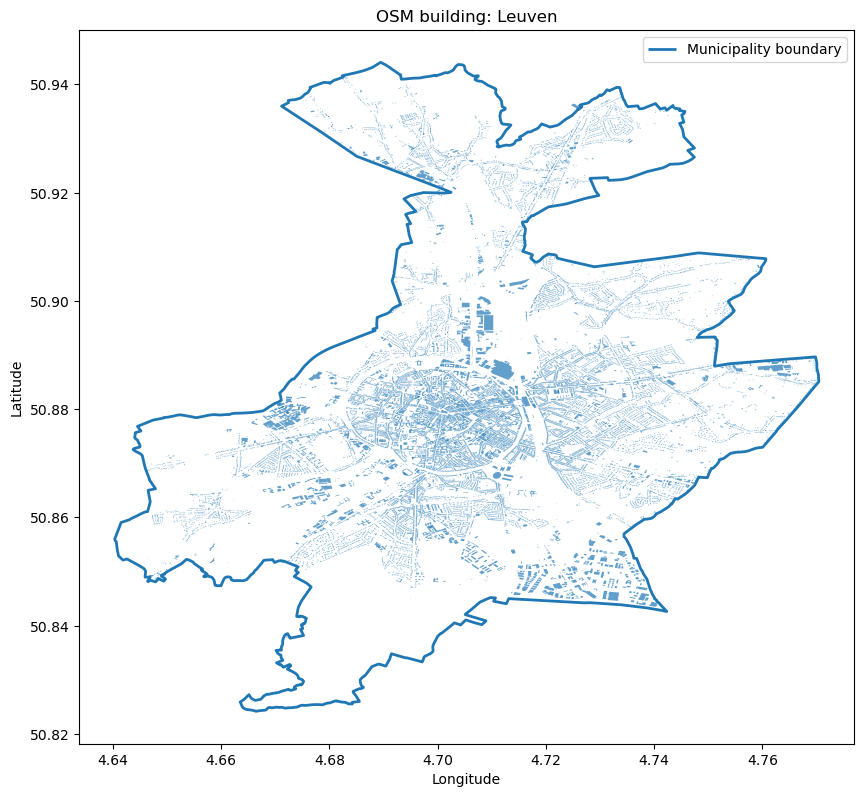

In [7]:
import matplotlib.pyplot as plt

gdf_boundary, gdf_buildings = fetch_leuven_buildings()

fig, ax = plt.subplots(figsize=(10, 10))

# Gebouwen in Leuven
if not gdf_buildings.empty:
    gdf_buildings.plot(ax=ax, alpha=0.7, linewidth=0, label="Buildings in Leuven", aspect=1)
else:
    print("Warning: no buildings found within Leuven.")

# Gemeentegrens erbovenop
gdf_boundary.boundary.plot(ax=ax, linewidth=2, label="Municipality boundary", aspect=1)

ax.set_title("OSM building: Leuven")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend()

plt.savefig("leuven_osm_buildings.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
# ============================================================
# SSI CALCULATION
# Modified version:
#   - Fixed threshold v_t = 22.22 m/s (Beaufort 9, 80 km/h)
#   - Building weight = absolute number of buildings (not fraction)
#   - Calibration factor c determined from training data
# ============================================================

V_THRESHOLD = 22.22  # m/s — Beaufort 9


def compute_ssi_daily(da):
    da = standardize_coords(da)
    excess = (da / V_THRESHOLD - 1.0).clip(min=0.0)
    ssi_daily = excess ** 3
    ssi_daily.name = 'ssi'
    return ssi_daily


def compute_ssi_per_gemeente(da, gdf_gemeenten, gdf_buildings=None, gemeente_col='gemeente'):
    ssi_daily = compute_ssi_daily(da)

    if gdf_buildings is not None:
        building_counts = (
            gdf_buildings.groupby(gemeente_col).size()
            .rename('n_buildings').reset_index()
        )
        totaal = building_counts['n_buildings'].sum()
        print(f'Absolute building weight enabled — total residential buildings: {totaal}')
        print(building_counts.sort_values('n_buildings', ascending=False).head(5).to_string(index=False))
    else:
        building_counts = None
        print('No building weight — pure hazard SSI')

    lats = da['lat'].values
    lons = da['lon'].values
    dlat = float(np.mean(np.diff(lats))) / 2
    dlon = float(np.mean(np.diff(lons))) / 2

    cell_polygons, cell_idx = [], []
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            cell_polygons.append(
                shapely.geometry.box(lon - dlon, lat - dlat, lon + dlon, lat + dlat)
            )
            cell_idx.append((i, j))

    gdf_cells = gpd.GeoDataFrame(
        {'lat_idx': [c[0] for c in cell_idx], 'lon_idx': [c[1] for c in cell_idx]},
        geometry=cell_polygons, crs=4326,
    )

    if gdf_gemeenten.crs != gdf_cells.crs:
        gdf_gemeenten = gdf_gemeenten.to_crs(4326)

    overlap = gpd.overlay(
        gdf_gemeenten[[gemeente_col, 'geometry']], gdf_cells, how='intersection'
    )
    overlap['weight'] = overlap.to_crs(3857).geometry.area

    records = []
    ssi_vals = ssi_daily.values  # (time, lat, lon)
    times = pd.to_datetime(da['time'].values)

    for gemeente, grp in overlap.groupby(gemeente_col):
        grp = grp.copy()
        grp['weight'] /= grp['weight'].sum()  
   
        weighted_ssi = np.zeros(len(times))
        for _, row in grp.iterrows():
            i, j = int(row['lat_idx']), int(row['lon_idx'])
            weighted_ssi += row['weight'] * ssi_vals[:, i, j]

  
        if building_counts is not None:
            n_bld = building_counts.loc[
                building_counts[gemeente_col] == gemeente, 'n_buildings'
            ].values
            weighted_ssi *= float(n_bld[0]) if len(n_bld) > 0 else 0.0

        for t, val in zip(times, weighted_ssi):
            records.append({
                gemeente_col: gemeente,
                'date': t,
                'year': t.year,
                'ssi_day': val,
            })

    df = pd.DataFrame(records)
    yearly = (
        df.groupby([gemeente_col, 'year'])['ssi_day'].sum()
        .reset_index().rename(columns={'ssi_day': 'ssi_yearly'})
    )

    if building_counts is not None:
        yearly = yearly.merge(
            building_counts[[gemeente_col, 'n_buildings']],
            on=gemeente_col, how='left'
        )
    return yearly


In [9]:
# ============================================================
# MAIN
# ============================================================

def run_model(
    era5_paths,
    gemeenten,
    assuralia,
    start_year=2015,
    end_year=2024,
    regrid=True,
    rg_res=0.25,
    min_lat=49.5, max_lat=51.5,
    min_lon=2.5, max_lon=6.4,
    train_years=None,
    gebruik_building_gewicht=True,
):

    print('=== 1. Load ERA5 ===')
    era_ds = load_era5_belgium(era5_paths)

    print('\n=== 2. OSM buildings ===')
    gdf_buildings, gdf_boundaries = fetch_buildings_multi_gemeente(gemeenten)
    gdf_residential = filter_residential_buildings(gdf_buildings)

    print('\n=== 3. Make it ready ===')
    da_full = era_ds['fg10'].sel(
        valid_time=slice(f'{start_year}-01-01', f'{end_year}-12-31')
    )
    da_full = standardize_coords(da_full)
    da_full = normalize_lon(da_full)
    da_full = da_full.rename({'valid_time': 'time'})

    if regrid:
        latout = np.arange(min_lat, max_lat + rg_res, rg_res)
        lonout = np.arange(min_lon, max_lon + rg_res, rg_res)
        da_full = da_full.interp(
            lat=latout, lon=lonout,
            method='linear',
            kwargs={'fill_value': 'extrapolate'}
        )

    da_full = collapse_to_daily_max(da_full, timedim='time')

    print('\n=== 4. SSI ===')
    ssi_df = compute_ssi_per_gemeente(
        da=da_full,
        gdf_gemeenten=gdf_boundaries,
        gdf_buildings=gdf_residential if gebruik_building_gewicht else None,
        gemeente_col='gemeente',
    )

    print('\n=== 5. Calibration ===')
    
    diagnostics = {
        'era_ds': era_ds,
        'da_full': da_full,
        'gdf_buildings': gdf_buildings,
        'gdf_boundaries': gdf_boundaries,
        'gdf_residential': gdf_residential,
        'ssi_per_gemeente': ssi_df,
        'scale_factor': scale,
    }
    return results_df, scale, diagnostics

In [10]:
# ============================================================
# ASSURALIA DATA
# ============================================================

df_raw = pd.read_excel(ASSURALIA_PATH, index_col=0)
assuralia = (
    df_raw.reset_index()
    .rename(columns={'index': 'year'})
    .melt(id_vars='year', var_name='gemeente', value_name='claims_assuralia')
)
assuralia['year'] = assuralia['year'].astype(int)

print(f'Assuralia Loaded: {len(assuralia)} rows, {assuralia["gemeente"].nunique()} cities')
print(assuralia.head(10))

Assuralia Loaded: 640 rows, 64 cities
   year  gemeente  claims_assuralia
0  2015  Aarschot                75
1  2016  Aarschot                68
2  2017  Aarschot                56
3  2018  Aarschot               236
4  2019  Aarschot               533
5  2020  Aarschot               433
6  2021  Aarschot               123
7  2022  Aarschot               601
8  2023  Aarschot               102
9  2024  Aarschot                46


=== ERA5 Loaded ===

=== OSM Buildings ===
📦 Cache: Aarschot
📦 Cache: Affligem
📦 Cache: Asse
📦 Cache: Beersel
📦 Cache: Begijnendijk
📦 Cache: Bekkevoort
📦 Cache: Bertem
📦 Cache: Bever
📦 Cache: Bierbeek
📦 Cache: Boortmeerbeek
📦 Cache: Boutersem
📦 Cache: Diest
📦 Cache: Dilbeek
📦 Cache: Drogenbos
📦 Cache: Geetbets
📦 Cache: Glabbeek
📦 Cache: Gooik
📦 Cache: Grimbergen
📦 Cache: Haacht
📦 Cache: Halle
📦 Cache: Herent
📦 Cache: Hoegaarden
📦 Cache: Hoeilaart
📦 Cache: Holsbeek
📦 Cache: Huldenberg
📦 Cache: Kampenhout
📦 Cache: Kapelle-op-den-Bos
📦 Cache: Keerbergen
📦 Cache: Kortenaken
📦 Cache: Kortenberg
📦 Cache: Kraainem
📦 Cache: Landen
📦 Cache: Lennik
📦 Cache: Leuven
📦 Cache: Liedekerke
📦 Cache: Linkebeek
📦 Cache: Linter
📦 Cache: Londerzeel
📦 Cache: Lubbeek
📦 Cache: Machelen
📦 Cache: Meise
📦 Cache: Merchtem
📦 Cache: Opwijk
📦 Cache: Oud-Heverlee
📦 Cache: Overijse
📦 Cache: Pajottegem
📦 Cache: Pepingen
📦 Cache: Roosdaal
📦 Cache: Rotselaar
📦 Cache: Scherpenheuvel-Zichem
📦 Cache: Sint-Genesius-Rode
📦 Ca

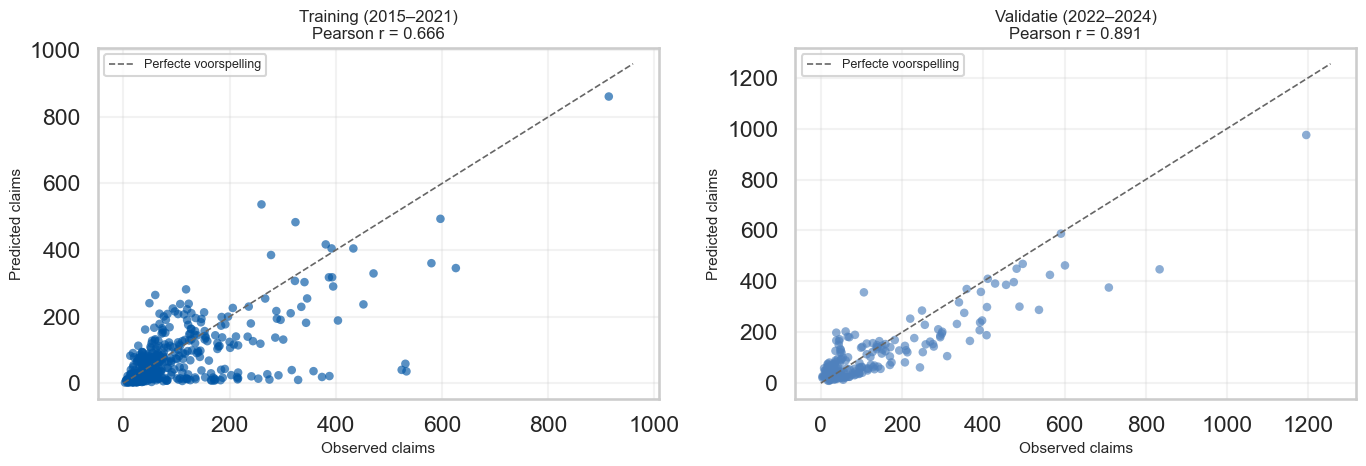

Plot 1 saved: fig_1_voorspeld_vs_werkelijk.png

Globale correlatie (alle jaren, alle gemeenten):
  Pearson  r = 0.7756, p = 0.0000
  Spearman r = 0.6140, p = 0.0000


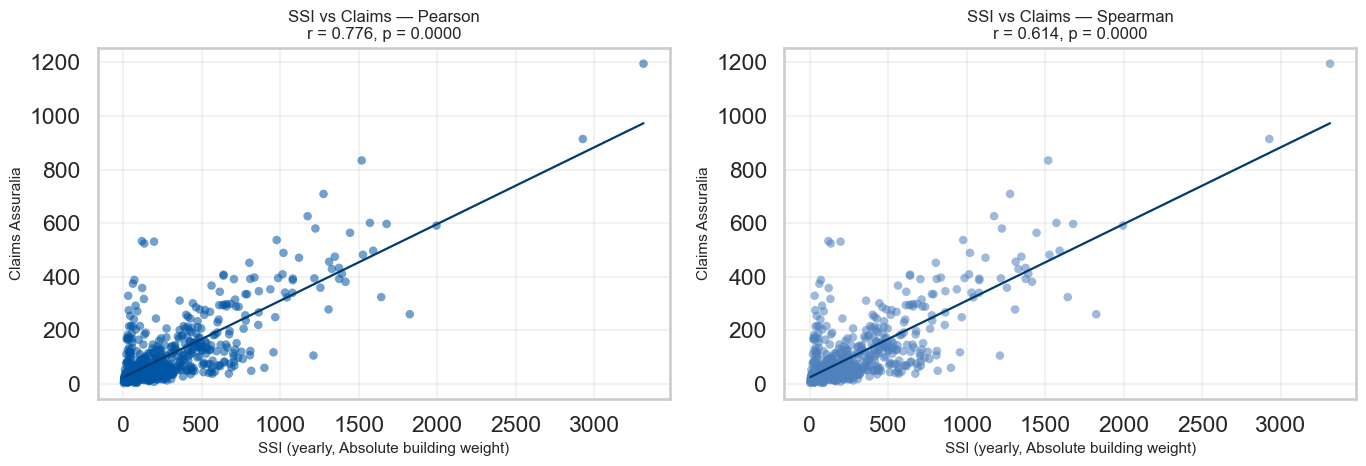

Plot 2 saved: fig_2_ssi_vs_claims_scatter.png


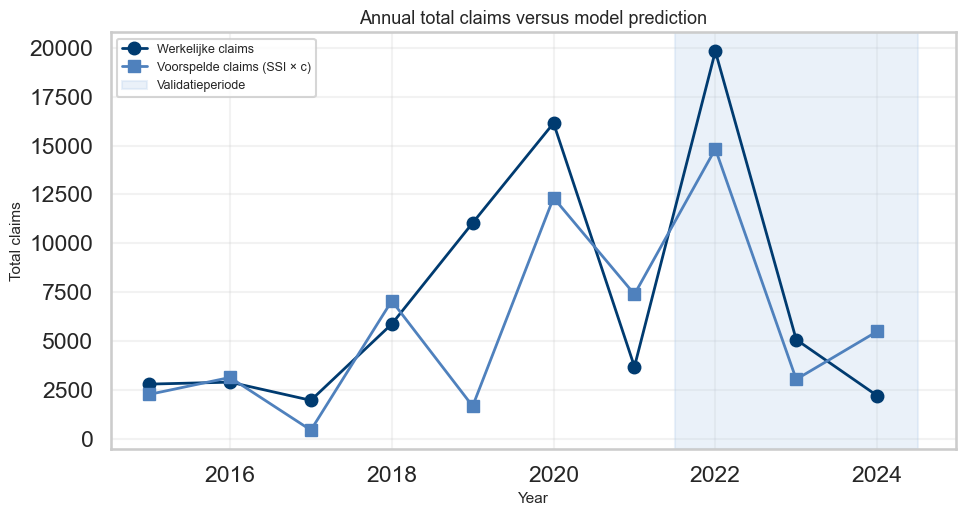

Plot 3 saved: fig_3_tijdreeks_claims_vs_voorspelling.png


/var/folders/1w/305gqzxd27lb54p0r6sxvfph0000gn/T/ipykernel_11251/3528539290.py:392: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1w/305gqzxd27lb54p0r6sxvfph0000gn/T/ipykernel_11251/3528539290.py:393: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig('fig_4_correlatie_per_gemeente.png', dpi=300, bbox_inches='tight')
/opt/anaconda3/envs/climada_env/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


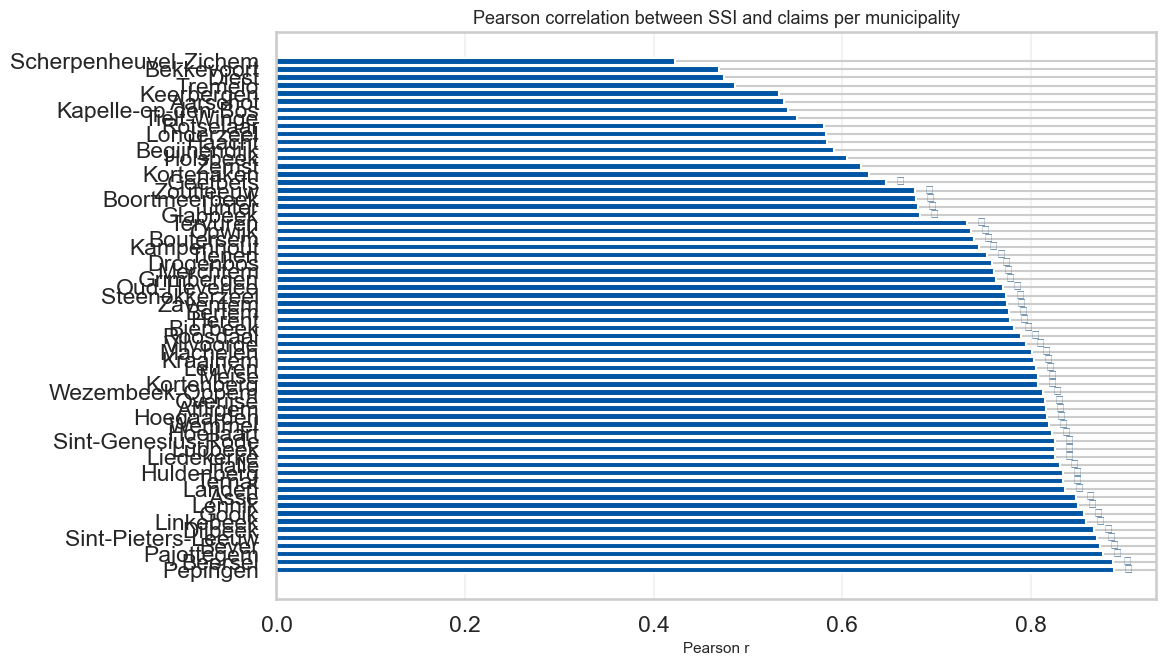

Plot 4 saved: fig_4_correlatie_per_gemeente.png


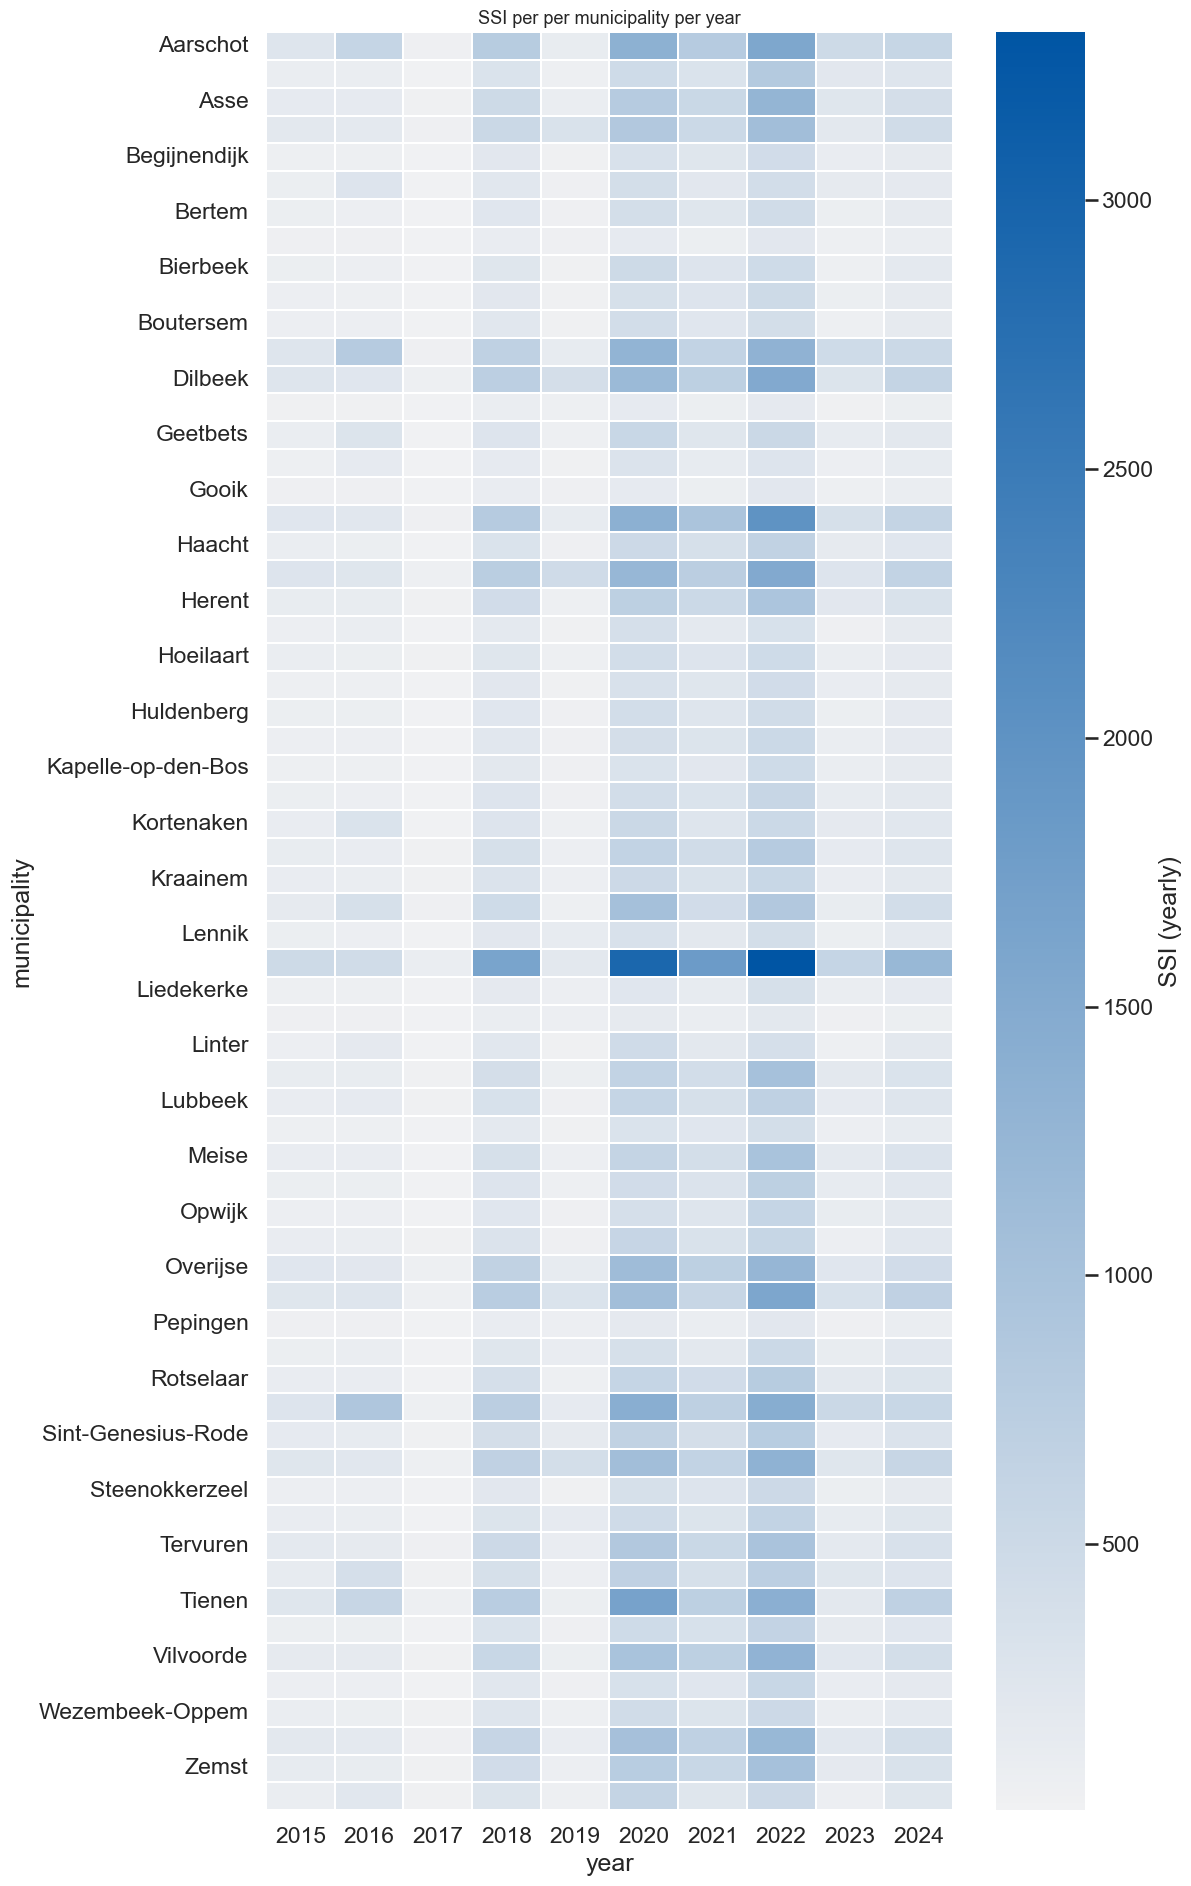

Plot 5 saved: fig_5_ssi_heatmap.png


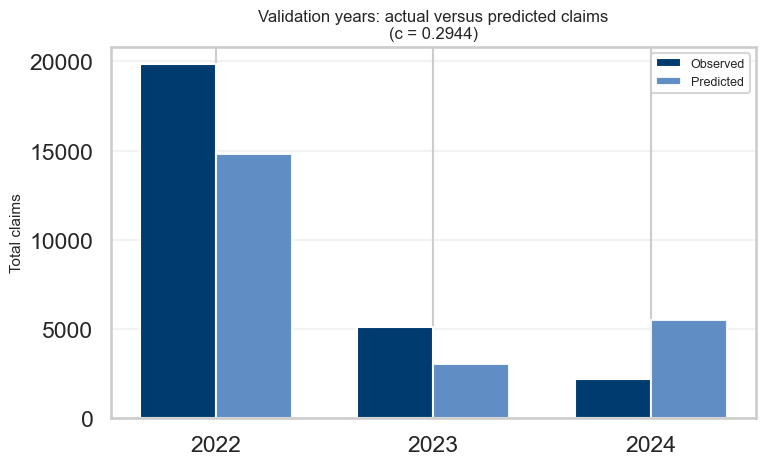

Plot 6 saved: fig_6_validatie_jaarlijks.png


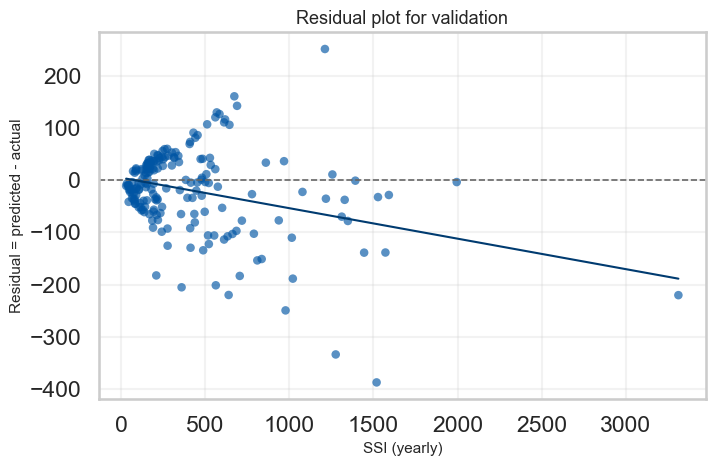

Plot 7 saved: fig_7_residuals_validatie.png


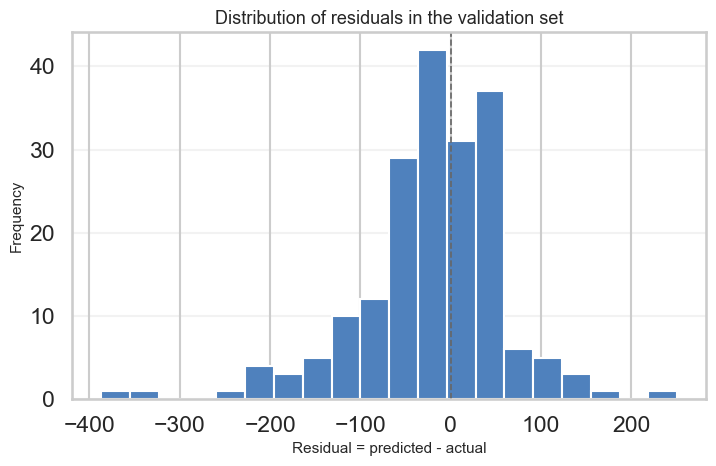

Plot 8 saved: fig_8_residuen_histogram.png


In [11]:
# ============================================================
# SSI + Calibration via OLS + VALIDATION
# ============================================================

from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

TRAIN_YEARS = list(range(2015, 2022))  # 2015 - 2021
VAL_YEARS   = list(range(2022, 2025))  # 2022 - 2024

# ------------------------------------------------------------
# Style
# ------------------------------------------------------------
KUL_DARK   = '#003B70'   
KUL_MID    = '#0055A4'   
KUL_LIGHT  = '#4F81BD'   
KUL_PALE   = '#AFCBEA'   
KUL_ACCENT = '#7AA6D8'   
GREY       = '#666666'
LIGHTGREY  = '#D9D9D9'

sns.set_theme(style='whitegrid', context='talk')

# ------------------------------------------------------------
# Helper
# ------------------------------------------------------------
def safe_pearsonr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 2:
        return np.nan, np.nan
    if np.all(x == x[0]) or np.all(y == y[0]):
        return np.nan, np.nan
    return stats.pearsonr(x, y)

def safe_spearmanr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) < 2:
        return np.nan, np.nan
    if np.all(x == x[0]) or np.all(y == y[0]):
        return np.nan, np.nan
    return stats.spearmanr(x, y)

def evaluate(df, label):
    if df.empty:
        print(f'\n--- {label} ---')
        print('  Dataset is leeg.')
        return {
            'label': label,
            'pearson_r': np.nan,
            'pearson_p': np.nan,
            'spearman_r': np.nan,
            'spearman_p': np.nan,
            'mae': np.nan,
            'rmse': np.nan,
            'bias_pct': np.nan,
        }

    y_true = df['claims_assuralia'].values.astype(float)
    y_pred = df['predicted_claims'].values.astype(float)

    mae  = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    r, p = safe_pearsonr(y_true, y_pred)
    r_s, p_s = safe_spearmanr(y_true, y_pred)

    if np.isclose(y_true.sum(), 0):
        bias = np.nan
    else:
        bias = (y_pred.sum() - y_true.sum()) / y_true.sum() * 100

    print(f'\n--- {label} ---')
    print(f'  Pearson r      : {r:.4f}  (p = {p:.4f})' if not np.isnan(r) else '  Pearson r      : n.v.t.')
    print(f'  Spearman r     : {r_s:.4f}  (p = {p_s:.4f})' if not np.isnan(r_s) else '  Spearman r     : n.v.t.')
    print(f'  MAE            : {mae:,.2f} claims')
    print(f'  RMSE           : {rmse:,.2f} claims')
    print(f'  Relatieve bias : {bias:+.1f}% (positief = overschatting)' if not np.isnan(bias) else '  Relatieve bias : n.v.t.')

    return {
        'label': label,
        'pearson_r': r,
        'pearson_p': p,
        'spearman_r': r_s,
        'spearman_p': p_s,
        'mae': mae,
        'rmse': rmse,
        'bias_pct': bias,
    }

# ------------------------------------------------------------
# ERA5 +  SSI Calibration
# ------------------------------------------------------------
print('=== ERA5 Loaded ===')
era_ds = load_era5_belgium(ERA5_PATHS)

print('\n=== OSM Buildings ===')
gdf_buildings, gdf_boundaries = fetch_buildings_multi_gemeente(GEMEENTEN)
gdf_residential = filter_residential_buildings(gdf_buildings)

print('\n=== Make it ready ===')
da_full = era_ds['fg10'].sel(valid_time=slice('2015-01-01', '2024-12-31'))
da_full = standardize_coords(da_full)
da_full = normalize_lon(da_full)
da_full = da_full.rename({'valid_time': 'time'})

# Regrid naar 0.25°
min_lat, max_lat, min_lon, max_lon, rg_res = 49.5, 51.5, 2.5, 6.4, 0.25
latout = np.arange(min_lat, max_lat + rg_res, rg_res)
lonout = np.arange(min_lon, max_lon + rg_res, rg_res)

da_full = da_full.interp(
    lat=latout,
    lon=lonout,
    method='linear',
    kwargs={'fill_value': 'extrapolate'}
)

da_full = collapse_to_daily_max(da_full, timedim='time')

print('\n=== SSI ===')
ssi_df = compute_ssi_per_gemeente(
    da=da_full,
    gdf_gemeenten=gdf_boundaries,
    gdf_buildings=gdf_residential,
    gemeente_col='gemeente',
)
print(ssi_df.head())

# ------------------------------------------------------------
#  Assuralia
# ------------------------------------------------------------
df_merged = ssi_df.merge(assuralia, on=['gemeente', 'year'], how='inner')
df_merged = df_merged.dropna(subset=['ssi_yearly', 'claims_assuralia']).copy()

print(f'\nSamengevoegde dataset: {len(df_merged)} rijen, '
      f'{df_merged["gemeente"].nunique()} gemeenten, '
      f'{df_merged["year"].nunique()} jaren')

if df_merged.empty:
    raise ValueError('The merged dataset is empty. Check the merge keys and input data.')

# ------------------------------------------------------------
# 8c. Train/Validation
# ------------------------------------------------------------
df_train = df_merged[df_merged['year'].isin(TRAIN_YEARS)].copy()
df_val   = df_merged[df_merged['year'].isin(VAL_YEARS)].copy()

print(f'\nTrainingsset : {len(df_train)} rijen ({TRAIN_YEARS[0]}–{TRAIN_YEARS[-1]})')
print(f'Validatieset : {len(df_val)} rijen ({VAL_YEARS[0]}–{VAL_YEARS[-1]})')

if df_train.empty:
    raise ValueError('The training set is empty. Check TRAIN_YEARS or the available years.')

# ------------------------------------------------------------
# c via OLS
# ------------------------------------------------------------
# Min: sum((claims - c * SSI)^2)
# c = sum(SSI * claims) / sum(SSI^2)
x_train = df_train['ssi_yearly'].values.astype(float)
y_train = df_train['claims_assuralia'].values.astype(float)

denom = np.dot(x_train, x_train)
if np.isclose(denom, 0):
    raise ValueError('Total SSI on training data is 0 — check the threshold value or ERA5 data.')

c = np.dot(x_train, y_train) / denom

print(f'\n=== Calibratiefactor (OLS) ===')
print(f' sum(SSI * claims) : {np.dot(x_train, y_train):,.4f}')
print(f'  sum(SSI²)         : {denom:,.4f}')
print(f'c = {c:.6f} claims / SSI-eenheid')

# ------------------------------------------------------------
# Prediction
# ------------------------------------------------------------
df_train['predicted_claims'] = df_train['ssi_yearly'] * c
df_val['predicted_claims']   = df_val['ssi_yearly']   * c

df_train['residual'] = df_train['predicted_claims'] - df_train['claims_assuralia']
df_val['residual']   = df_val['predicted_claims']   - df_val['claims_assuralia']

# ------------------------------------------------------------
# Evaluation
# ------------------------------------------------------------
print('\n=== Evaluation ===')
metrics_train = evaluate(df_train, f'Training ({TRAIN_YEARS[0]}–{TRAIN_YEARS[-1]})')
metrics_val   = evaluate(df_val,   f'Validatie ({VAL_YEARS[0]}–{VAL_YEARS[-1]})')

# ------------------------------------------------------------
# Correlation per city 
# ------------------------------------------------------------
corr_per_gemeente = []

for gemeente, grp in df_merged.groupby('gemeente'):
    grp = grp.dropna(subset=['ssi_yearly', 'claims_assuralia']).copy()

    if len(grp) < 3:
        continue

    x = grp['ssi_yearly'].values.astype(float)
    y = grp['claims_assuralia'].values.astype(float)

    r_p, p_p = safe_pearsonr(x, y)
    r_s, p_s = safe_spearmanr(x, y)

    corr_per_gemeente.append({
        'gemeente': gemeente,
        'n': len(grp),
        'pearson_r': round(r_p, 4) if not np.isnan(r_p) else np.nan,
        'pearson_p': round(p_p, 4) if not np.isnan(p_p) else np.nan,
        'spearman_r': round(r_s, 4) if not np.isnan(r_s) else np.nan,
        'spearman_p': round(p_s, 4) if not np.isnan(p_s) else np.nan,
        'pearson_sig': '✓' if (not np.isnan(p_p) and p_p < 0.05) else '',
        'spearman_sig': '✓' if (not np.isnan(p_s) and p_s < 0.05) else '',
    })

df_corr_gemeente = pd.DataFrame(corr_per_gemeente)

if not df_corr_gemeente.empty:
    df_corr_gemeente = df_corr_gemeente.sort_values('pearson_r', ascending=False)
    print('\n=== Correlation SSI vs Claims for each city ===')
    print(df_corr_gemeente.to_string(index=False))
else:
    print('\nWarning: no valid municipal correlations were calculated.')
    df_corr_gemeente = pd.DataFrame(columns=[
        'gemeente', 'n', 'pearson_r', 'pearson_p',
        'spearman_r', 'spearman_p', 'pearson_sig', 'spearman_sig'
    ])

# ------------------------------------------------------------
# 8h. CSV files 
# ------------------------------------------------------------
df_merged.to_csv('ssi_claims_merged.csv', index=False)
df_train.to_csv('ssi_train.csv', index=False)
df_val.to_csv('ssi_validatie.csv', index=False)
df_corr_gemeente.to_csv('correlatie_per_gemeente.csv', index=False)
pd.DataFrame([metrics_train, metrics_val]).to_csv('evaluatie_metrics.csv', index=False)

print('\nCSV files saved.')

# ------------------------------------------------------------
# 8i. Extra tabels
# ------------------------------------------------------------
train_yearly = df_train.groupby('year').agg(
    werkelijk=('claims_assuralia', 'sum'),
    voorspeld=('predicted_claims', 'sum'),
    ssi=('ssi_yearly', 'sum')
).reset_index()

val_yearly = df_val.groupby('year').agg(
    werkelijk=('claims_assuralia', 'sum'),
    voorspeld=('predicted_claims', 'sum'),
    ssi=('ssi_yearly', 'sum')
).reset_index()

all_yearly = df_merged.copy()
all_yearly['predicted_claims_fullsample'] = all_yearly['ssi_yearly'] * c
all_yearly = all_yearly.groupby('year').agg(
    werkelijk=('claims_assuralia', 'sum'),
    voorspeld=('predicted_claims_fullsample', 'sum'),
    ssi=('ssi_yearly', 'sum')
).reset_index()

# ============================================================
# PLOT 1 — Predicted vs Actual (training + validation)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_specs = [
    (df_train, f'Training ({TRAIN_YEARS[0]}–{TRAIN_YEARS[-1]})', KUL_MID),
    (df_val,   f'Validatie ({VAL_YEARS[0]}–{VAL_YEARS[-1]})',    KUL_LIGHT),
]

for ax, (df_plot, label, kleur) in zip(axes, plot_specs):
    if df_plot.empty:
        ax.text(0.5, 0.5, 'Geen data', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(label, fontsize=12)
        ax.axis('off')
        continue

    y_true = df_plot['claims_assuralia'].values
    y_pred = df_plot['predicted_claims'].values
    r, _ = safe_pearsonr(y_true, y_pred)

    ax.scatter(y_true, y_pred, alpha=0.65, edgecolors='none', color=kleur, s=38)

    lim = max(y_true.max(), y_pred.max()) * 1.05 if len(y_true) > 0 else 1
    ax.plot([0, lim], [0, lim], linestyle='--', lw=1.2, color=GREY, label='Perfecte voorspelling')

    ax.set_xlabel('Observed claims', fontsize=11)
    ax.set_ylabel('Predicted claims', fontsize=11)
    ax.set_title(
        f'{label}\nPearson r = {r:.3f}' if not np.isnan(r) else f'{label}\nPearson r = n.v.t.',
        fontsize=12
    )
    ax.legend(fontsize=9, frameon=True)
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('fig_1_voorspeld_vs_werkelijk.png', dpi=300, bbox_inches='tight')
plt.show()
print('Plot 1 saved: fig_1_voorspeld_vs_werkelijk.png')

# ============================================================
# PLOT 2 — SSI vs Claims (full period)
# ============================================================
x_all = df_merged['ssi_yearly'].values.astype(float)
y_all = df_merged['claims_assuralia'].values.astype(float)
r_p_all, p_p_all = safe_pearsonr(x_all, y_all)
r_s_all, p_s_all = safe_spearmanr(x_all, y_all)

print(f'\nGlobale correlatie (alle jaren, alle gemeenten):')
print(f'  Pearson  r = {r_p_all:.4f}, p = {p_p_all:.4f}' if not np.isnan(r_p_all) else '  Pearson  r = n.v.t.')
print(f'  Spearman r = {r_s_all:.4f}, p = {p_s_all:.4f}' if not np.isnan(r_s_all) else '  Spearman r = n.v.t.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (methode, r, p, kleur) in zip(axes, [
    ('Pearson', r_p_all, p_p_all, KUL_MID),
    ('Spearman', r_s_all, p_s_all, KUL_LIGHT),
]):
    ax.scatter(x_all, y_all, alpha=0.55, edgecolors='none', color=kleur, s=38)

    if len(np.unique(x_all)) > 1:
        m, b = np.polyfit(x_all, y_all, 1)
        xline = np.linspace(x_all.min(), x_all.max(), 100)
        ax.plot(xline, m * xline + b, color=KUL_DARK, lw=1.6)

    ax.set_xlabel('SSI (yearly, Absolute building weight)', fontsize=11)
    ax.set_ylabel('Claims Assuralia', fontsize=11)
    ax.set_title(
        f'SSI vs Claims — {methode}\nr = {r:.3f}, p = {p:.4f}' if not np.isnan(r) else f'SSI vs Claims — {methode}\nr = n.v.t.',
        fontsize=12
    )
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('fig_2_ssi_vs_claims_scatter.png', dpi=300, bbox_inches='tight')
plt.show()
print('Plot 2 saved: fig_2_ssi_vs_claims_scatter.png')

# ============================================================
# PLOT 3 — Annual claims vs prediction
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(all_yearly['year'], all_yearly['werkelijk'],
        marker='o', lw=2.0, color=KUL_DARK, label='Werkelijke claims')
ax.plot(all_yearly['year'], all_yearly['voorspeld'],
        marker='s', lw=2.0, color=KUL_LIGHT, label='Voorspelde claims (SSI × c)')

if len(VAL_YEARS) > 0:
    ax.axvspan(min(VAL_YEARS) - 0.5, max(VAL_YEARS) + 0.5,
               color=KUL_PALE, alpha=0.25, label='Validatieperiode')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Total claims', fontsize=11)
ax.set_title('Annual total claims versus model prediction', fontsize=13)
ax.legend(fontsize=9, frameon=True)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('fig_3_tijdreeks_claims_vs_voorspelling.png', dpi=300, bbox_inches='tight')
plt.show()
print('Plot 3 saved: fig_3_tijdreeks_claims_vs_voorspelling.png')

# ============================================================
# PLOT 4 — Pearson r for each city
# ============================================================
if not df_corr_gemeente.empty:
    fig, ax = plt.subplots(figsize=(12, 7))

    kleuren = [
        KUL_MID if (not pd.isna(r) and r >= 0) else KUL_ACCENT
        for r in df_corr_gemeente['pearson_r']
    ]

    ax.barh(df_corr_gemeente['gemeente'], df_corr_gemeente['pearson_r'], color=kleuren)
    ax.axvline(0, color=GREY, lw=0.9)
    ax.set_xlabel('Pearson r', fontsize=11)
    ax.set_title('Pearson correlation between SSI and claims per municipality', fontsize=13)
    ax.grid(True, axis='x', alpha=0.25)

    for i, row in df_corr_gemeente.reset_index(drop=True).iterrows():
        if row['pearson_sig'] == '✓' and not pd.isna(row['pearson_r']):
            ax.text(row['pearson_r'] + 0.01, i, '✓', va='center', fontsize=9, color=KUL_DARK)

    plt.tight_layout()
    plt.savefig('fig_4_correlatie_per_gemeente.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Plot 4 saved: fig_4_correlatie_per_gemeente.png')
else:
    print('Plot 4 skipped: no correlations available.')

# ============================================================
# PLOT 5 — Heatmap SSI per municipality per year
# ============================================================
ssi_pivot = df_merged.pivot(index='gemeente', columns='year', values='ssi_yearly')

if not ssi_pivot.empty:
    fig, ax = plt.subplots(figsize=(12, max(6, len(ssi_pivot) * 0.3)))
    sns.heatmap(
        ssi_pivot,
        cmap=sns.light_palette(KUL_MID, as_cmap=True),
        linewidths=0.25,
        ax=ax,
        cbar_kws={'label': 'SSI (yearly)'}
    )

    ax.set_title('SSI per per municipality per year', fontsize=13)
    ax.set_xlabel('year')
    ax.set_ylabel('municipality')

    plt.tight_layout()
    plt.savefig('fig_5_ssi_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Plot 5 saved: fig_5_ssi_heatmap.png')
else:
    print('Plot 5 skipped: empty pivot table.')

# ============================================================
# PLOT 6 — Validation
# ============================================================
if not val_yearly.empty:
    fig, ax = plt.subplots(figsize=(8, 5))

    x_pos = np.arange(len(val_yearly))
    breedte = 0.35

    ax.bar(x_pos - breedte/2, val_yearly['werkelijk'], breedte,
           label='Observed', color=KUL_DARK)
    ax.bar(x_pos + breedte/2, val_yearly['voorspeld'], breedte,
           label='Predicted', color=KUL_LIGHT, alpha=0.9)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(val_yearly['year'].astype(str))
    ax.set_ylabel('Total claims', fontsize=11)
    ax.set_title(f'Validation years: actual versus predicted claims\n(c = {c:.4f})', fontsize=12)
    ax.legend(fontsize=9, frameon=True)
    ax.grid(True, axis='y', alpha=0.25)

    plt.tight_layout()
    plt.savefig('fig_6_validatie_jaarlijks.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Plot 6 saved: fig_6_validatie_jaarlijks.png')
else:
    print('Plot 6 skipped: no validation years.')

# ============================================================
# PLOT 7 — Residual plot validation
# ============================================================
if not df_val.empty and 'residual' in df_val.columns:
    fig, ax = plt.subplots(figsize=(7.5, 5))

    ax.scatter(df_val['ssi_yearly'], df_val['residual'],
               color=KUL_MID, alpha=0.65, s=38, edgecolors='none')
    ax.axhline(0, color=GREY, linestyle='--', lw=1.2)

    if len(df_val) >= 2 and len(np.unique(df_val['ssi_yearly'])) > 1:
        m, b = np.polyfit(df_val['ssi_yearly'], df_val['residual'], 1)
        xline = np.linspace(df_val['ssi_yearly'].min(), df_val['ssi_yearly'].max(), 100)
        ax.plot(xline, m * xline + b, color=KUL_DARK, lw=1.5)

    ax.set_xlabel('SSI (yearly)', fontsize=11)
    ax.set_ylabel('Residual = predicted - actual', fontsize=11)
    ax.set_title('Residual plot for validation', fontsize=13)
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.savefig('fig_7_residuals_validatie.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Plot 7 saved: fig_7_residuals_validatie.png')
else:
    print('Plot 7 skipped: no residuals.')

# ============================================================
# PLOT 8 — Distribution of residuals
# ============================================================
if not df_val.empty and 'residual' in df_val.columns:
    fig, ax = plt.subplots(figsize=(7.5, 5))

    ax.hist(df_val['residual'], bins=20, color=KUL_LIGHT, edgecolor='white')
    ax.axvline(0, color=GREY, linestyle='--', lw=1.2)

    ax.set_xlabel('Residual = predicted - actual', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title('Distribution of residuals in the validation set', fontsize=13)
    ax.grid(True, axis='y', alpha=0.25)

    plt.tight_layout()
    plt.savefig('fig_8_residuen_histogram.png', dpi=300, bbox_inches='tight')
    plt.show()
    print('Plot 8 saved: fig_8_residuen_histogram.png')
else:
    print('Plot 8 skipped: no residuals.')

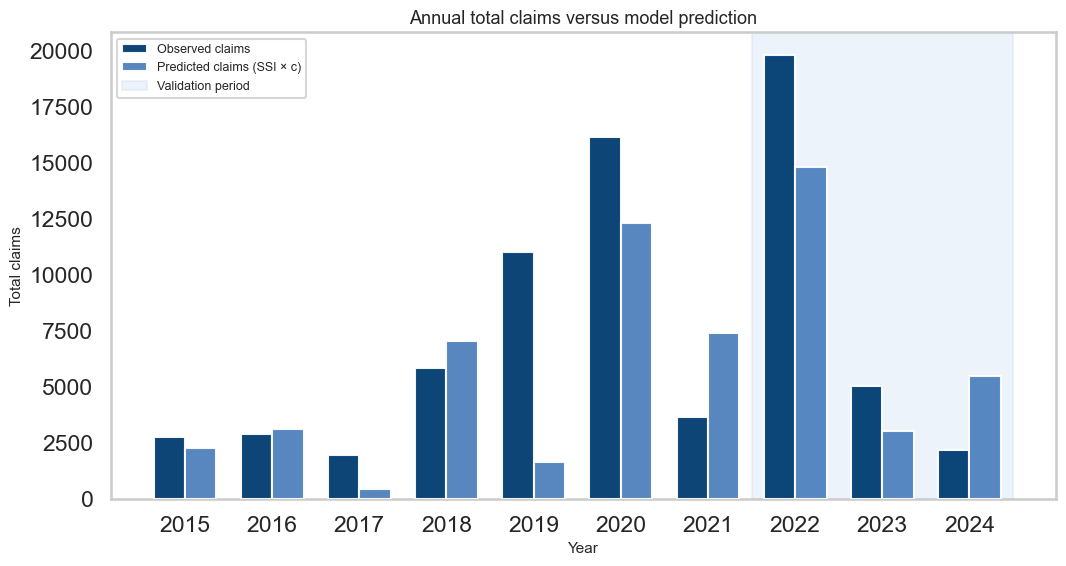

Plot 3 saved: fig_3_annual_claims_vs_prediction.png


In [12]:
# ============================================================
# PLOT 3 — Annual total claims vs model prediction (bar chart)
# ============================================================
fig, ax = plt.subplots(figsize=(11, 6))

years = all_yearly['year'].astype(int).values
observed = all_yearly['werkelijk'].values
predicted = all_yearly['voorspeld'].values

x = np.arange(len(years))
width = 0.36

# Highlight validation period
if len(VAL_YEARS) > 0:
    val_mask = np.isin(years, VAL_YEARS)
    val_idx = np.where(val_mask)[0]
    if len(val_idx) > 0:
        ax.axvspan(
            val_idx[0] - 0.5,
            val_idx[-1] + 0.5,
            color=KUL_PALE,
            alpha=0.22,
            zorder=0,
            label='Validation period'
        )

# Bars
ax.bar(
    x - width/2,
    observed,
    width,
    label='Observed claims',
    color=KUL_DARK,
    alpha=0.95,
    zorder=3
)

ax.bar(
    x + width/2,
    predicted,
    width,
    label='Predicted claims (SSI × c)',
    color=KUL_LIGHT,
    alpha=0.95,
    zorder=3
)

# Axes
ax.set_xticks(x)
ax.set_xticklabels(years.astype(str))
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Total claims', fontsize=11)
ax.set_title('Annual total claims versus model prediction', fontsize=13)

# Grid
#ax.grid(True, axis='y', alpha=0.25, zorder=0)
ax.grid(False)

# Legend ordering
handles, labels = ax.get_legend_handles_labels()
if 'Validation period' in labels:
    idx = labels.index('Validation period')
    h_val = handles.pop(idx)
    l_val = labels.pop(idx)
    handles.append(h_val)
    labels.append(l_val)

ax.legend(handles, labels, fontsize=9, frameon=True)

plt.tight_layout()
plt.savefig('fig_3_annual_claims_vs_prediction.png', dpi=300, bbox_inches='tight')
plt.show()

print('Plot 3 saved: fig_3_annual_claims_vs_prediction.png')

In [13]:
# ============================================================
# Kaart: ERA5 grid points over Flemish Brabant
# ============================================================
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point

def plot_era5_grid_points_vlaams_brabant(
    da,
    gdf_boundaries,
    title="ERA5 grid points over Flemish Brabant",
    output_path="fig_era5_grid_points_vlaams_brabant.png"
):
    # --------------------------------------------
    # 1. Neem boundary en zet CRS goed
    # --------------------------------------------
    gdf_bnd = gdf_boundaries.copy()

    if gdf_bnd.crs is None:
        gdf_bnd = gdf_bnd.set_crs(4326)

    # --------------------------------------------
    # 2. Maak GeoDataFrame van alle ERA5 gridpunten
    # --------------------------------------------
    lats = da["lat"].values
    lons = da["lon"].values

    points = []
    for lat in lats:
        for lon in lons:
            points.append({"lon": float(lon), "lat": float(lat), "geometry": Point(float(lon), float(lat))})

    gdf_points = gpd.GeoDataFrame(points, geometry="geometry", crs="EPSG:4326")

    # --------------------------------------------
    # 3. Hou enkel punten in of nabij Vlaams-Brabant
    #    (binnen de bbox van de gemeenten)
    # --------------------------------------------
    minx, miny, maxx, maxy = gdf_bnd.total_bounds

    gdf_points = gdf_points[
        (gdf_points["lon"] >= minx) &
        (gdf_points["lon"] <= maxx) &
        (gdf_points["lat"] >= miny) &
        (gdf_points["lat"] <= maxy)
    ].copy()

    # --------------------------------------------
    # 4. Plot
    # --------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 10))

    # Gemeenten
    gdf_bnd.boundary.plot(
        ax=ax,
        color="grey",
        linewidth=1.0
    )

    # ERA5 punten
    gdf_points.plot(
        ax=ax,
        color=KUL_DARK if "KUL_DARK" in globals() else "darkblue",
        markersize=35,
        marker="o",
        label="ERA5 grid point"
    )

    # Optioneel: coordinaten als labels
    for _, row in gdf_points.iterrows():
        ax.text(
            row.geometry.x,
            row.geometry.y,
            f"({row['lon']:.2f}, {row['lat']:.2f})",
            fontsize=7,
            ha="left",
            va="bottom"
        )

    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend(frameon=True)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved as: {output_path}")
    print(f"Number of plotted ERA5 grid points: {len(gdf_points)}")

    return gdf_points

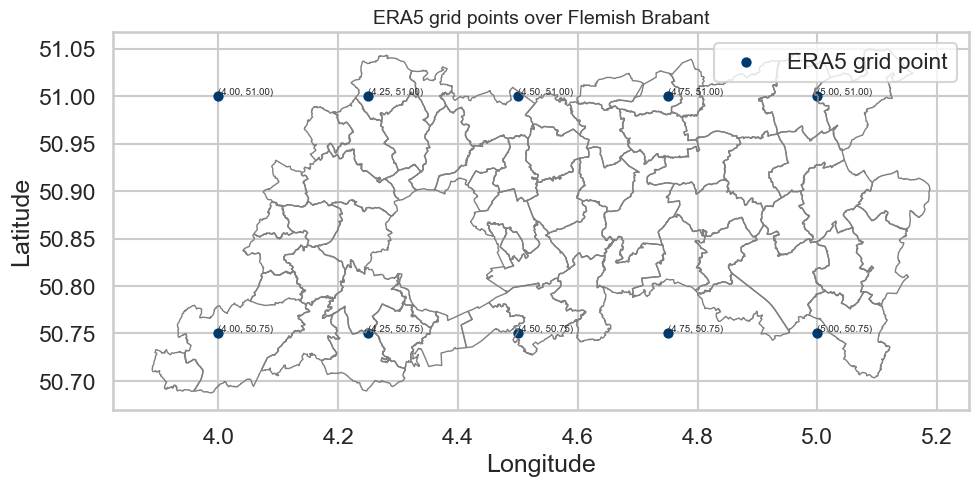

Saved as: fig_era5_grid_points_vlaams_brabant.png
Number of plotted ERA5 grid points: 10


In [14]:
gdf_era5_points = plot_era5_grid_points_vlaams_brabant(
    da=da_full,
    gdf_boundaries=gdf_boundaries,
    title="ERA5 grid points over Flemish Brabant",
    output_path="fig_era5_grid_points_vlaams_brabant.png"
)

In [15]:
point_A = da_full.sel(lon=4.00, lat=50.75, method="nearest")
point_B = da_full.sel(lon=5.00, lat=51.00, method="nearest")

In [16]:
import pandas as pd

df_compare = pd.DataFrame({
    "time": point_A["time"].values,
    "wind_A": point_A.values,
    "wind_B": point_B.values,
})

df_compare["year"] = pd.to_datetime(df_compare["time"]).dt.year

yearly = df_compare.groupby("year").agg(
    wind_A_max=("wind_A", "max"),
    wind_B_max=("wind_B", "max"),
    wind_A_mean=("wind_A", "mean"),
    wind_B_mean=("wind_B", "mean"),
).reset_index()

print(yearly)

   year  wind_A_max  wind_B_max  wind_A_mean  wind_B_mean
0  2015   26.478714   27.263916    11.819877    11.785033
1  2016   26.312588   30.963409    11.119390    11.162262
2  2017   24.758728   25.435593    11.369519    11.497445
3  2018   28.711639   29.440613    11.436704    11.414959
4  2019   27.888931   26.425064    11.869637    11.817128
5  2020   30.168549   31.551743    12.990235    12.997162
6  2021   28.149338   28.768936    11.131838    11.184151
7  2022   29.599945   30.610931    11.596946    11.538695
8  2023   28.326324   30.076752    12.778291    13.092925
9  2024   29.149529   29.128830    11.530437    11.643481


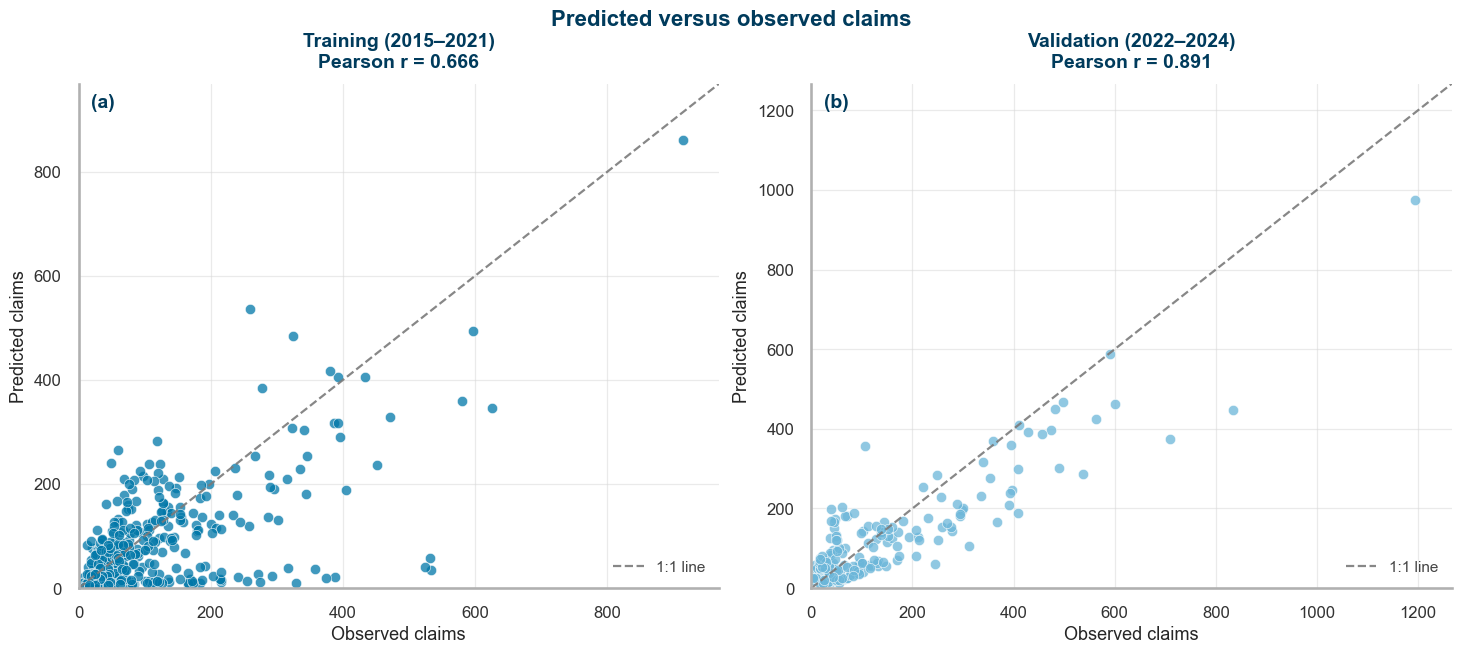

Plot 1 saved: fig_1_predicted_vs_observed_thesis_style.png

Overall correlation (all years, all municipalities):
  Pearson  r = 0.7756, p = 0.0000
  Spearman r = 0.6140, p = 0.0000


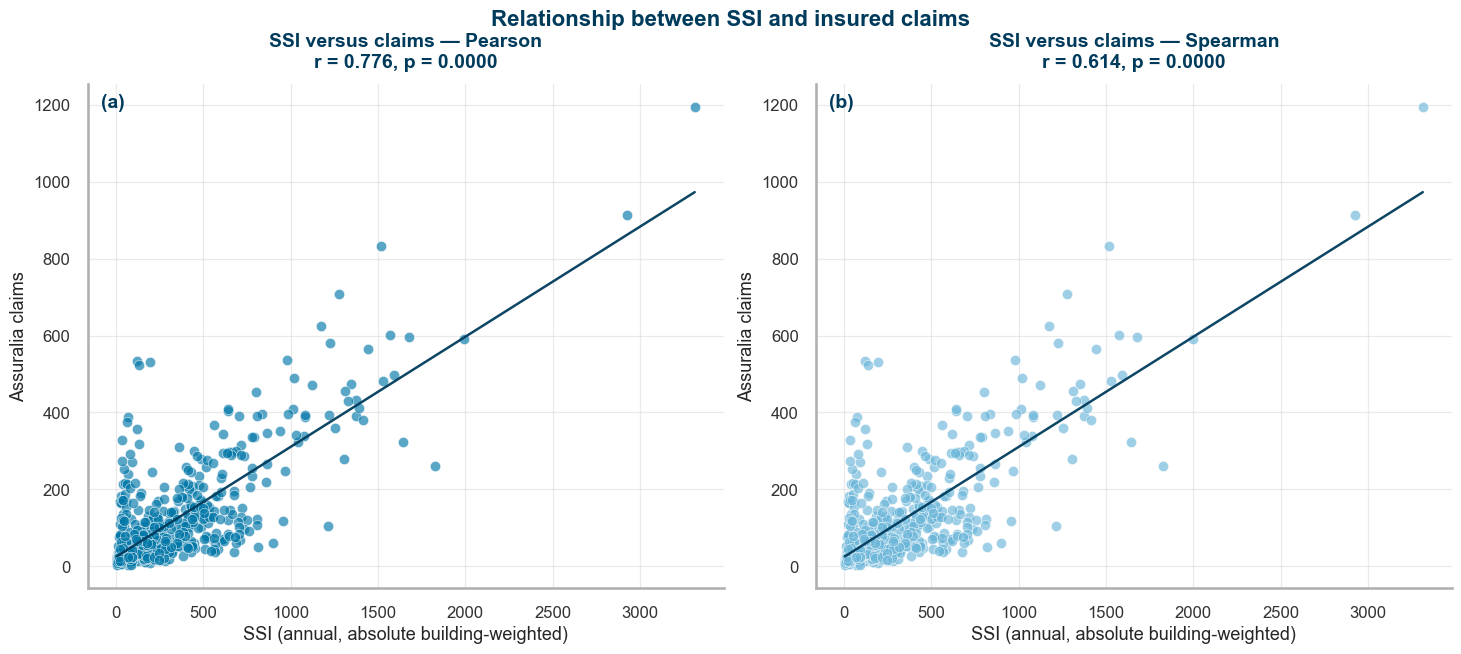

Plot 2 saved: fig_2_ssi_vs_claims_scatter_thesis_style.png


In [29]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# THESIS-STYLE MATPLOTLIB SETTINGS — LARGER VERSION
# ============================================================

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",

    # General font sizes
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 13,
    "legend.fontsize": 11,

    # Style
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlepad": 12,
})

# KUL-like palette
KUL_DARK   = "#003B5C"
KUL_MID    = "#0077A8"
KUL_LIGHT  = "#6BB6D9"
GREY       = "#7A7A7A"
LIGHT_GREY = "#D9D9D9"

def style_axes(ax):
    """Apply a clean and consistent thesis style to axes."""
    ax.grid(True, which="major", color=LIGHT_GREY, linewidth=0.9, alpha=0.55)
    ax.set_axisbelow(True)

    ax.spines["left"].set_color("#B0B0B0")
    ax.spines["bottom"].set_color("#B0B0B0")

    # Larger axis numbers
    ax.tick_params(axis="both", colors="#333333", labelsize=12)

def add_panel_label(ax, label):
    """Add panel label such as (a), (b), ... in the upper-left corner."""
    ax.text(
        0.02, 0.98, label,
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=14,
        fontweight="bold",
        color=KUL_DARK
    )

# ============================================================
# PLOT 1 — Predicted vs Observed (training + validation)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.2), constrained_layout=True)

plot_specs = [
    (df_train, f'Training ({TRAIN_YEARS[0]}–{TRAIN_YEARS[-1]})', KUL_MID, "(a)"),
    (df_val,   f'Validation ({VAL_YEARS[0]}–{VAL_YEARS[-1]})',   KUL_LIGHT, "(b)"),
]

for ax, (df_plot, label, colour, panel) in zip(axes, plot_specs):

    if df_plot.empty:
        ax.text(
            0.5, 0.5, 'No data available',
            ha='center', va='center',
            transform=ax.transAxes,
            fontsize=13
        )
        ax.set_title(label, fontsize=14)
        ax.axis('off')
        continue

    y_true = df_plot['claims_assuralia'].values.astype(float)
    y_pred = df_plot['predicted_claims'].values.astype(float)

    r, _ = safe_pearsonr(y_true, y_pred)

    # Axis limits with a small margin
    lim_min = 0
    lim_max = max(np.max(y_true), np.max(y_pred)) * 1.06 if len(y_true) > 0 else 1

    # Scatter plot — larger points
    ax.scatter(
        y_true, y_pred,
        s=55,
        alpha=0.75,
        color=colour,
        edgecolor="white",
        linewidth=0.5
    )

    # 1:1 line
    ax.plot(
        [lim_min, lim_max], [lim_min, lim_max],
        linestyle="--",
        linewidth=1.6,
        color=GREY,
        alpha=0.9,
        label="1:1 line"
    )

    ax.set_xlim(lim_min, lim_max)
    ax.set_ylim(lim_min, lim_max)

    ax.set_xlabel("Observed claims", fontsize=13)
    ax.set_ylabel("Predicted claims", fontsize=13)

    subtitle = f"Pearson r = {r:.3f}" if not np.isnan(r) else "Pearson r = n.a."

    ax.set_title(
        f"{label}\n{subtitle}",
        color=KUL_DARK,
        fontsize=14,
        fontweight="bold"
    )

    style_axes(ax)
    add_panel_label(ax, panel)

    leg = ax.legend(loc="lower right", frameon=False, fontsize=11)
    for text in leg.get_texts():
        text.set_color("#444444")

fig.suptitle(
    "Predicted versus observed claims",
    fontsize=16,
    fontweight="bold",
    color=KUL_DARK,
    y=1.03
)

plt.savefig("fig_1_predicted_vs_observed_thesis_style.png", dpi=300, bbox_inches="tight")
plt.show()

print("Plot 1 saved: fig_1_predicted_vs_observed_thesis_style.png")


# ============================================================
# PLOT 2 — SSI vs Claims (full period)
# ============================================================

x_all = df_merged['ssi_yearly'].values.astype(float)
y_all = df_merged['claims_assuralia'].values.astype(float)

r_p_all, p_p_all = safe_pearsonr(x_all, y_all)
r_s_all, p_s_all = safe_spearmanr(x_all, y_all)

print("\nOverall correlation (all years, all municipalities):")
print(f"  Pearson  r = {r_p_all:.4f}, p = {p_p_all:.4f}" if not np.isnan(r_p_all) else "  Pearson  r = n.a.")
print(f"  Spearman r = {r_s_all:.4f}, p = {p_s_all:.4f}" if not np.isnan(r_s_all) else "  Spearman r = n.a.")

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.2), constrained_layout=True)

specs = [
    ("Pearson",  r_p_all, p_p_all, KUL_MID,   "(a)"),
    ("Spearman", r_s_all, p_s_all, KUL_LIGHT, "(b)"),
]

for ax, (method, r, p, colour, panel) in zip(axes, specs):

    ax.scatter(
        x_all, y_all,
        s=55,
        alpha=0.65,
        color=colour,
        edgecolor="white",
        linewidth=0.5
    )

    # Regression line if meaningful
    if len(np.unique(x_all)) > 1:
        m, b = np.polyfit(x_all, y_all, 1)
        xline = np.linspace(np.min(x_all), np.max(x_all), 200)

        ax.plot(
            xline, m * xline + b,
            color=KUL_DARK,
            linewidth=1.8,
            alpha=0.95
        )

    ax.set_xlabel("SSI (annual, absolute building-weighted)", fontsize=13)
    ax.set_ylabel("Assuralia claims", fontsize=13)

    if not np.isnan(r):
        ax.set_title(
            f"SSI versus claims — {method}\nr = {r:.3f}, p = {p:.4f}",
            color=KUL_DARK,
            fontsize=14,
            fontweight="bold"
        )
    else:
        ax.set_title(
            f"SSI versus claims — {method}\nr = n.a.",
            color=KUL_DARK,
            fontsize=14,
            fontweight="bold"
        )

    style_axes(ax)
    add_panel_label(ax, panel)

fig.suptitle(
    "Relationship between SSI and insured claims",
    fontsize=16,
    fontweight="bold",
    color=KUL_DARK,
    y=1.03
)

plt.savefig("fig_2_ssi_vs_claims_scatter_thesis_style.png", dpi=300, bbox_inches="tight")
plt.show()

print("Plot 2 saved: fig_2_ssi_vs_claims_scatter_thesis_style.png")

In [23]:
def plot_pearson_spearman_side_by_side(
    gdf_boundaries,
    df_corr,
    gemeente_col="gemeente",
    pearson_col="pearson_r",
    spearman_col="spearman_r",
    output_path="fig_map_pearson_vs_spearman.png"
):
    import geopandas as gpd
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    import pandas as pd
    import numpy as np
    from matplotlib.colors import LinearSegmentedColormap

    # ------------------------------------------------------------
    # KU Leuven blue colormap (diverging around 0)
    # ------------------------------------------------------------
    cmap = LinearSegmentedColormap.from_list(
        "kul_blue_diverging",
        [
            "#08306B",
            "#4292C6",
            "#DEEBF7",
            "#F7FBFF",
            "#DEEBF7",
            "#4292C6",
            "#08306B"
        ]
    )

    # ------------------------------------------------------------
    # Clean names
    # ------------------------------------------------------------
    gdf_map = gdf_boundaries.copy()
    df_corr = df_corr.copy()

    gdf_map["gemeente_clean"] = gdf_map[gemeente_col].astype(str).str.strip()
    df_corr["gemeente_clean"] = df_corr["gemeente"].astype(str).str.strip()

    # ------------------------------------------------------------
    # Merge
    # ------------------------------------------------------------
    gdf_plot = gdf_map.merge(
        df_corr[["gemeente_clean", pearson_col, spearman_col]],
        on="gemeente_clean",
        how="left"
    )

    gdf_plot = gdf_plot[
        gdf_plot.geometry.notna() & ~gdf_plot.geometry.is_empty
    ].copy()

    # ------------------------------------------------------------
    # Shared symmetric color scale
    # ------------------------------------------------------------
    vals = pd.concat([
        gdf_plot[pearson_col],
        gdf_plot[spearman_col]
    ]).dropna()

    vmax = max(abs(vals.min()), abs(vals.max()))
    if np.isclose(vmax, 0):
        vmax = 1.0

    norm = mpl.colors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    cols = [pearson_col, spearman_col]
    titles = ["Pearson correlation", "Spearman correlation"]

    for ax, col, title in zip(axes, cols, titles):

        gdf_plot.plot(
            column=col,
            ax=ax,
            cmap=cmap,
            norm=norm,
            edgecolor="grey",
            linewidth=1.0,
            missing_kwds={
                "color": "lightgrey",
                "edgecolor": "grey",
                "label": "No data"
            },
            legend=False
        )

        # ------------------------------------------------------------
        # Municipality labels
        # ------------------------------------------------------------
        for _, row in gdf_plot.iterrows():
            if row.geometry is None or row.geometry.is_empty:
                continue

            if pd.isna(row[col]):
                continue

            point = row.geometry.representative_point()

            ax.text(
                point.x,
                point.y,
                f"{row[col]:.2f}",
                ha="center",
                va="center",
                fontsize=10,
                color="white",
                fontweight="bold"
            )

        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_axis_off()

 

    # ------------------------------------------------------------
    # Layout
    # ------------------------------------------------------------
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved as: {output_path}")

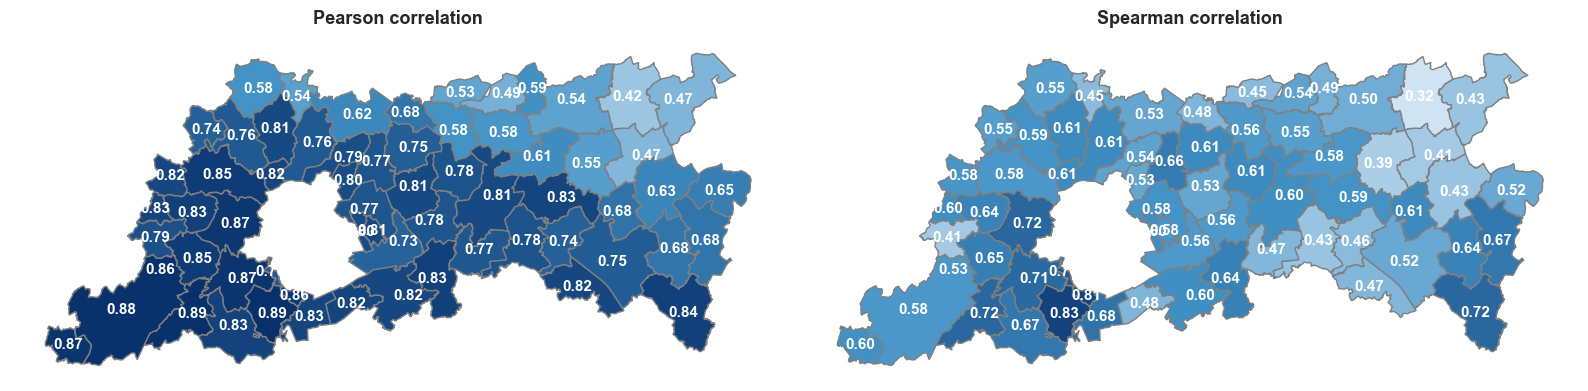

Saved as: fig_map_pearson_vs_spearman.png


In [24]:
plot_pearson_spearman_side_by_side(
    gdf_boundaries,
    df_corr_gemeente
)

### 